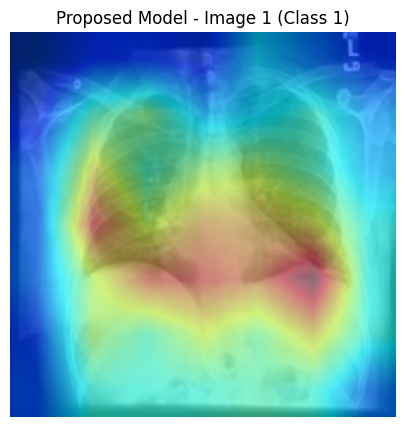

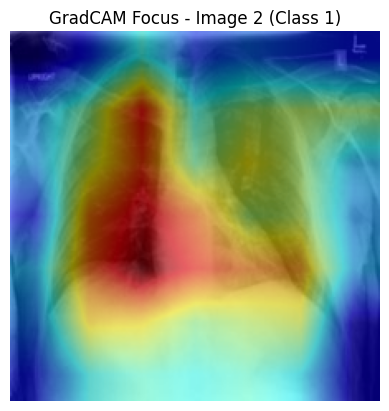

{'Pneumonia': array([[[  2,  33, 106],
         [  0,  32, 109],
         [  1,  32, 109],
         ...,
         [  1,  33, 171],
         [  0,  32, 170],
         [  0,  33, 169]],
 
        [[  1,  33, 108],
         [  0,  34, 106],
         [  0,  33, 110],
         ...,
         [  0,  33, 172],
         [  0,  33, 171],
         [  0,  35, 168]],
 
        [[  2,  33, 104],
         [  0,  31, 108],
         [  0,  33, 106],
         ...,
         [  0,  33, 174],
         [  0,  32, 173],
         [  0,  32, 175]],
 
        ...,
 
        [[  0,  52, 169],
         [  1,  56, 172],
         [  2,  54, 169],
         ...,
         [  1,  81, 171],
         [  0,  82, 170],
         [  0,  85, 170]],
 
        [[  0,  51, 168],
         [  0,  54, 171],
         [  1,  53, 170],
         ...,
         [  1,  81, 168],
         [  0,  80, 168],
         [  0,  84, 170]],
 
        [[  0,  52, 165],
         [  0,  54, 171],
         [  0,  53, 169],
         ...,
         [  0, 

In [45]:
import torch
import torch.nn as nn
import torchvision.models as models
import numpy as np
import cv2
import torchvision.transforms as transforms
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from PIL import Image
import matplotlib.pyplot as plt

# 🔹 Define Model (Ensure consistency with your training)
class MyCNN(nn.Module):
    def __init__(self):
        super(MyCNN, self).__init__()
        self.features = models.resnet18(pretrained=False)
        self.features.fc = nn.Linear(512, 14)  # Adjust output layer

    def forward(self, x):
        return self.features(x)

# 🔹 Load Trained Model
model = MyCNN()
state_dict = torch.load("/mnt/Internal/MedImage/CheXpert Dataset/Lab_Rotation_2/training_CNN_Models_On_new_diffusion_generated_data/model_epoch_10.pth", map_location=torch.device("cpu"))
model.load_state_dict(state_dict, strict=False)
model.eval()

# 🔹 Image Preprocessing Function
def preprocess_image(img_path):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    image = Image.open(img_path).convert("RGB")
    return transform(image).unsqueeze(0)  # Add batch dimension

# 🔹 Load & Preprocess Images
img1_path = "/mnt/Internal/MedImage/CheXpert Dataset/Lab_Rotation_2/training_our_own_diffusion_model/256_diffusion_model_with_prompt/rough_folder_for_img_checking/Pneumonia1.png"
#img2_path = "/mnt/Internal/MedImage/CheXpert Dataset/Lab_Rotation_2/training_our_own_diffusion_model/256_diffusion_model_with_prompt/rough_folder_for_img_checking/Pneumonia2.png"
img2_path = "/mnt/Internal/MedImage/CheXpert Dataset/Lab_Rotation_2/training_our_own_diffusion_model/256_diffusion_model_with_prompt/train/patient01500/study1/view1_frontal.jpg"

img1_tensor = preprocess_image(img1_path)
img2_tensor = preprocess_image(img2_path)

# 🔹 Combine into a batch
X = torch.cat([img1_tensor, img2_tensor], dim=0)

# 🔹 GradCAM Setup (Target Last Conv Layer)
target_layer = model.features.layer4[-1]  # Last conv layer in ResNet18
gradcam = GradCAM(model=model, target_layers=[target_layer])

# 🔹 Get Model Predictions
output = model(X)

# 🔹 Select Target Class (Predicted Class for Each Image)
target_class1 = output[0].argmax().item()
target_class2 = output[1].argmax().item()
targets = [ClassifierOutputTarget(target_class1), ClassifierOutputTarget(target_class2)]

# 🔹 Compute GradCAM Heatmaps
grayscale_cam = gradcam(input_tensor=X, targets=targets)  # Shape: (2, 224, 224)

# 🔹 Convert Original Images to NumPy for Visualization
img1_array = np.array(Image.open(img1_path).convert("RGB").resize((224, 224))) / 255.0
img2_array = np.array(Image.open(img2_path).convert("RGB").resize((224, 224))) / 255.0

# 🔹 Overlay Heatmaps
heatmap1 = show_cam_on_image(img1_array, grayscale_cam[0], use_rgb=True)
heatmap2 = show_cam_on_image(img2_array, grayscale_cam[1], use_rgb=True)

# 🔹 Display Images in Jupyter Notebook
plt.figure(figsize=(10, 5))

#plt.subplot(1, 2, 1)
plt.imshow(heatmap1)
plt.title(f"Proposed Model - Image 1 (Class {target_class1})")
plt.axis("off")
plt.show()
#plt.subplot(1, 2, 2)
plt.imshow(heatmap2)
plt.title(f"GradCAM Focus - Image 2 (Class {target_class2})")
plt.axis("off")

plt.show()

# 🔹 Save the GradCAM Output
cv2.imwrite("Proposed Model.jpg", cv2.cvtColor(heatmap1, cv2.COLOR_RGB2BGR))
cv2.imwrite("gradcam_image2.jpg", cv2.cvtColor(heatmap2, cv2.COLOR_RGB2BGR))

# ✅ Return GradCAM Heatmaps as NumPy Arrays
gradcam_outputs = {
    "Pneumonia": heatmap1,
    "image2": heatmap2
}

gradcam_outputs


In [ ]:
ls "/mnt/Internal/MedImage/CheXpert Dataset/Lab_Rotation_2/densnet12_real_vs_real_training/model_epoch_9.pth"

checkpoint_epoch_2_iter_4800.pth   model_epoch_2.pth
checkpoint_epoch_3_iter_9600.pth   model_epoch_3.pth
checkpoint_epoch_4_iter_4800.pth   model_epoch_4.pth
checkpoint_epoch_5_iter_14400.pth  model_epoch_5.pth
checkpoint_epoch_6_iter_19200.pth  model_epoch_6.pth
checkpoint_epoch_8_iter_24000.pth  model_epoch_7.pth
checkpoint_epoch_9_iter_28800.pth  model_epoch_8.pth
model_epoch_10.pth                 model_epoch_9.pth
model_epoch_1.pth


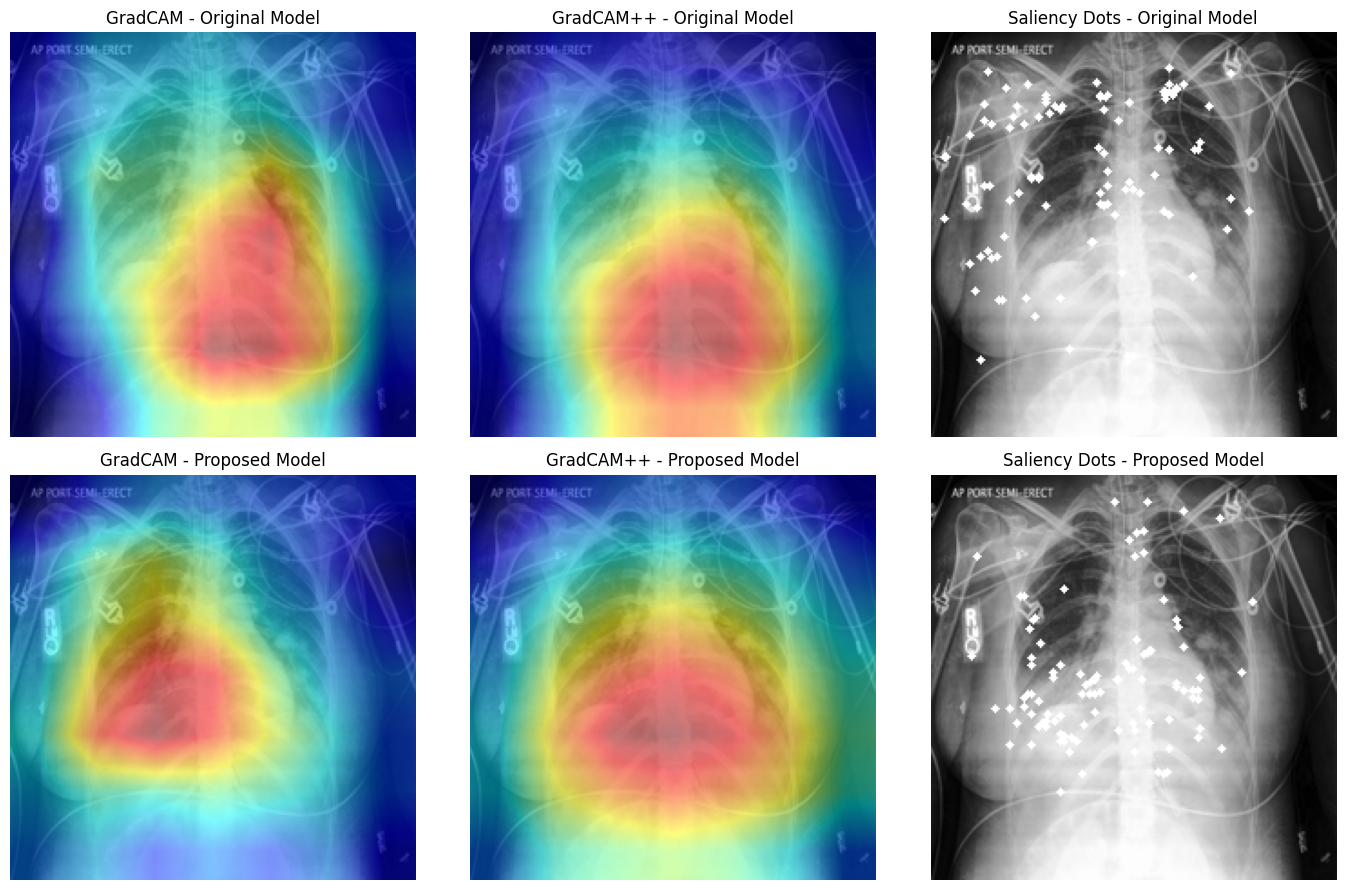

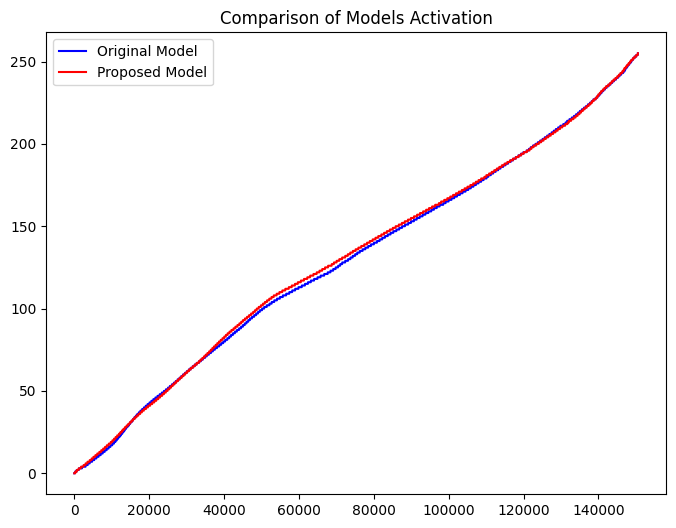

In [141]:
import torch
import torch.nn as nn
import torchvision.models as models
import numpy as np
import cv2
import torchvision.transforms as transforms
from pytorch_grad_cam import GradCAM, GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from PIL import Image
import matplotlib.pyplot as plt

# 🔹 Define Two Models
class Model1(nn.Module):
    def __init__(self):
        super(Model1, self).__init__()
        self.features = models.resnet18(pretrained=False)
        self.features.fc = nn.Linear(512, 14)

    def forward(self, x):
        return self.features(x)

class Model2(nn.Module):
    def __init__(self):
        super(Model2, self).__init__()
        self.features = models.resnet34(pretrained=False)
        self.features.fc = nn.Linear(512, 14)

    def forward(self, x):
        return self.features(x)

# 🔹 Load Trained Models
model1 = Model1()
state_dict1 = torch.load("/mnt/Internal/MedImage/CheXpert Dataset/Lab_Rotation_2/densnet12_real_vs_real_training/model_epoch_9.pth", map_location=torch.device("cpu"))
model1.load_state_dict(state_dict1, strict=False)
model1.eval()

model2 = Model2()
state_dict2 = torch.load("/mnt/Internal/MedImage/CheXpert Dataset/Lab_Rotation_2/training_CNN_Models_On_new_diffusion_generated_data/model_epoch_10.pth", map_location=torch.device("cpu"))
model2.load_state_dict(state_dict2, strict=False)
model2.eval()

# 🔹 Image Preprocessing Function
def preprocess_image(img_path):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    image = Image.open(img_path).convert("RGB")
    return transform(image).unsqueeze(0)

# 🔹 Load & Preprocess Image
img_path = "/mnt/Internal/MedImage/CheXpert Dataset/unzip_chexpert_images/CheXpert-v1.0/train/patient37943/study1/view1_frontal.jpg"
img_tensor = preprocess_image(img_path)

# 🔹 GradCAM Setup
target_layer1 = model1.features.layer4[-1]
gradcam1 = GradCAM(model=model1, target_layers=[target_layer1])
gradcam_plus_plus1 = GradCAMPlusPlus(model=model1, target_layers=[target_layer1])

target_layer2 = model2.features.layer4[-1]
gradcam2 = GradCAM(model=model2, target_layers=[target_layer2])
gradcam_plus_plus2 = GradCAMPlusPlus(model=model2, target_layers=[target_layer2])

# 🔹 Get Predictions
output1 = model1(img_tensor)
output2 = model2(img_tensor)

target_class1 = output1.argmax().item()
target_class2 = output2.argmax().item()

targets1 = [ClassifierOutputTarget(target_class1)]
targets2 = [ClassifierOutputTarget(target_class2)]

# 🔹 GradCAM Heatmaps
grayscale_cam1 = gradcam1(input_tensor=img_tensor, targets=targets1)
grayscale_cam_plus_plus1 = gradcam_plus_plus1(input_tensor=img_tensor, targets=targets1)

grayscale_cam2 = gradcam2(input_tensor=img_tensor, targets=targets2)
grayscale_cam_plus_plus2 = gradcam_plus_plus2(input_tensor=img_tensor, targets=targets2)

# 🔹 Convert Original Image to NumPy for Visualization
img_array = np.array(Image.open(img_path).convert("RGB").resize((224, 224))) / 255.0

heatmap1 = show_cam_on_image(img_array, grayscale_cam1[0], use_rgb=True)
heatmap2 = show_cam_on_image(img_array, grayscale_cam2[0], use_rgb=True)
heatmap1_plus_plus = show_cam_on_image(img_array, grayscale_cam_plus_plus1[0], use_rgb=True)
heatmap2_plus_plus = show_cam_on_image(img_array, grayscale_cam_plus_plus2[0], use_rgb=True)

# 🔹 Saliency Map Function
def compute_saliency_map(model, input_tensor, target_class):
    input_tensor = input_tensor.clone().detach().requires_grad_(True)
    model.eval()
    output = model(input_tensor)
    model.zero_grad()
    class_score = output[0, target_class]
    class_score.backward()
    saliency = input_tensor.grad.abs().detach().squeeze().cpu().numpy()
    saliency = np.max(saliency, axis=0)
    saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-8)
    return saliency

# 🔹 Saliency Overlay with Light Dots
def overlay_saliency_dots(image, saliency_map, top_k=100):
    img = image.copy()
    saliency_flat = saliency_map.flatten()
    topk_indices = np.argpartition(saliency_flat, -top_k)[-top_k:]
    topk_coords = np.array(np.unravel_index(topk_indices, saliency_map.shape)).T
    for y, x in topk_coords:
        cv2.circle(img, (x, y), radius=2, color=(1.0, 1.0, 1.0), thickness=-1)
    return img

# 🔹 Compute Saliency Maps
saliency_map1 = compute_saliency_map(model1, img_tensor.clone(), target_class1)
saliency_map2 = compute_saliency_map(model2, img_tensor.clone(), target_class2)

saliency_dot_img1 = overlay_saliency_dots(img_array, saliency_map1, top_k=100)
saliency_dot_img2 = overlay_saliency_dots(img_array, saliency_map2, top_k=100)

# 🔹 Plot Results in Desired Order
plt.figure(figsize=(14, 9))

# ─── Row 1: Original Model ───
plt.subplot(2, 3, 1)
plt.imshow(heatmap1)
plt.title("GradCAM - Original Model")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(heatmap1_plus_plus)
plt.title("GradCAM++ - Original Model")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(saliency_dot_img1)
plt.title("Saliency Dots - Original Model")
plt.axis("off")

# ─── Row 2: Proposed Model ───
plt.subplot(2, 3, 4)
plt.imshow(heatmap2)
plt.title("GradCAM - Proposed Model")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(heatmap2_plus_plus)
plt.title("GradCAM++ - Proposed Model")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(saliency_dot_img2)
plt.title("Saliency Dots - Proposed Model")
plt.axis("off")

plt.tight_layout()
plt.show()

# 🔹 Save Outputs
cv2.imwrite("model1_gradcam.jpg", cv2.cvtColor(heatmap1, cv2.COLOR_RGB2BGR))
cv2.imwrite("model2_gradcam.jpg", cv2.cvtColor(heatmap2, cv2.COLOR_RGB2BGR))
cv2.imwrite("model1_gradcam_plus_plus.jpg", cv2.cvtColor(heatmap1_plus_plus, cv2.COLOR_RGB2BGR))
cv2.imwrite("model2_gradcam_plus_plus.jpg", cv2.cvtColor(heatmap2_plus_plus, cv2.COLOR_RGB2BGR))
cv2.imwrite("model1_saliency_dots.jpg", (saliency_dot_img1 * 255).astype(np.uint8))
cv2.imwrite("model2_saliency_dots.jpg", (saliency_dot_img2 * 255).astype(np.uint8))

# 🔹 Line Histogram of GradCAM Intensities
heatmap1_flat = heatmap1.flatten()
heatmap2_flat = heatmap2.flatten()

plt.figure(figsize=(8, 6))
plt.plot(np.sort(heatmap1_flat), label='Original Model', color='blue')
plt.plot(np.sort(heatmap2_flat), label='Proposed Model', color='red')
plt.title('Comparison of Models Activation')
plt.legend()
plt.show()

# ✅ Return GradCAM Outputs
gradcam_outputs = {
    "Original Model-GradCam": heatmap1,
    "Proposed Model-GradCam": heatmap2,
    "Original Model-GradCam++": heatmap1_plus_plus,
    "Proposed Model-GradCam++": heatmap2_plus_plus,
}
